## CCA performance test

In [1]:
import os

import numpy as np
from getdist import plots, MCSamples, loadMCSamples
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy import stats as st
from sbi.inference import NLE
from sbi.utils import BoxUniform
import torch
from tqdm import tqdm
from nautilus import Sampler as NautilusSampler, Prior as NautilusPrior
import functools

import jax
import jax_cosmo as jc
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

devices = jax.devices()
print(f"JAX devices: {devices}")

JAX devices: [CudaDevice(id=0)]


## Notebook outline

First, let's define some helper functions

## Some helper functions

In [42]:
def triangle_plot(
    mc_samples,
    truth=None,
    params_to_plot=None,
    savefig=False,
    filename=None,
):
    plt.close()
    with mpl.rc_context():
        g = plots.getSubplotPlotter()
        g.settings.figure_legend_frame = False
        g.settings.alpha_filled_add = 0.6
        g.settings.axes_fontsize = 18
        g.settings.legend_fontsize = 18
        g.settings.lab_fontsize = 18

        n_samples = len(mc_samples) if isinstance(mc_samples, (list, tuple)) else 1
        base_ls = ["-", "--", ":", "-."]
        contour_ls = [base_ls[i % len(base_ls)] for i in range(n_samples)]

        if params_to_plot:
            g.triangle_plot(
                mc_samples,
                params=params_to_plot,
                filled_compare=False,
                normalized=True,
                contour_ls=contour_ls,
            )
        else:
            g.triangle_plot(
                mc_samples,
                filled_compare=False,
                normalized=True,
                contour_ls=contour_ls,
            )

        if truth is not None:
            g.add_param_markers(truth, color="black", ls="--")

        plt.subplots_adjust(hspace=0, wspace=0)

        if savefig:
            plt.savefig(filename, bbox_inches="tight")
        plt.show()

def draw_weighted_posterior_samples(points, log_w, n_draws=10000, seed=None):
    """Draw posterior samples with replacement using normalized importance weights."""
    w = np.exp(log_w - np.max(log_w))
    w /= w.sum()

    rng = np.random.default_rng(seed)
    idx = rng.choice(points.shape[0], size=n_draws, replace=True, p=w)
    return points[idx]  

## For a cosmic shear simulator, we need to first define some redshift bins

Here we are making use of smail distributions of widening width, defined as

$$
n(z)=z_a \exp{(z/z_0)^b}
$$

This defines for us the number density of "objects", in our case galaxies, in a given tomographic bin. 

We can think of each tomographic bin as a "shell" of observations going further away from us that we have banded together. 

We have split our mock galaxy survey into 5 tomographic bins.

In [3]:
nz1 = jc.redshift.smail_nz(1., 2.,  0.5)
nz2 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 0.6), 0.5)
nz3 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 0.8), 1.2)
nz4 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 1.0), 1.8)
nz5 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 1.2), 2.4)

nzs = [nz1, nz2, nz3, nz4, nz5]

## Let's also plot it to convince ourselves things are looking right

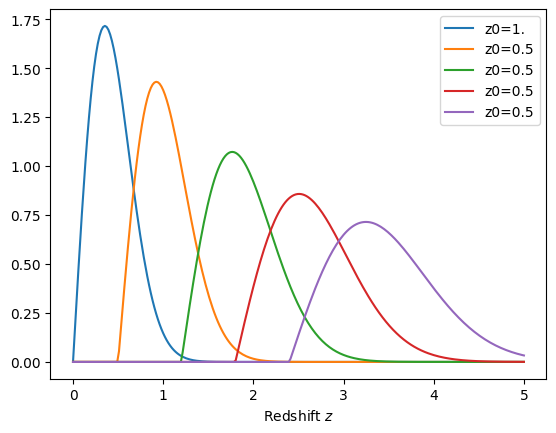

In [4]:
# And let's plot it
z = np.linspace(0,5,256)

# Redshift distributions are callable, and they return the normalized distribution
plt.plot(z, nz1(z), label='z0=1.')
plt.plot(z, nz2(z), label='z0=0.5')
plt.plot(z, nz3(z), label='z0=0.5')
plt.plot(z, nz4(z), label='z0=0.5')
plt.plot(z, nz5(z), label='z0=0.5')
plt.legend()
plt.xlabel('Redshift $z$');

## We also need to define some probes to describe what exactly we are observing

In [5]:
probes = [jc.probes.WeakLensing(nzs, sigma_e=0.26),]

## Lastly we also need to define the ell range that we want our power spectrum to go up to

In [6]:
ell = np.logspace(np.log10(2), np.log10(1000), 100)

## Let's run a cosmological simulator to calculate a lensing power spectrum with our parameter setup

In [7]:
cosmo_data = jc.Planck15()

In [8]:
cls = jc.angular_cl.angular_cl(cosmo_data, ell, probes)
noise_cls = jc.angular_cl.noise_cl(ell, probes)
cov = jc.angular_cl.gaussian_cl_covariance(ell, probes, cls, noise_cls, sparse=False)
cls_noise = jax.random.multivariate_normal(mean=jnp.concatenate(cls), cov=cov, key=jax.random.PRNGKey(42))

## Let's plot this all to see what our data vector looks like

So here we are plotting the auto power spectrum and cross power spectrum across all of the tomographic bins for weak lensing

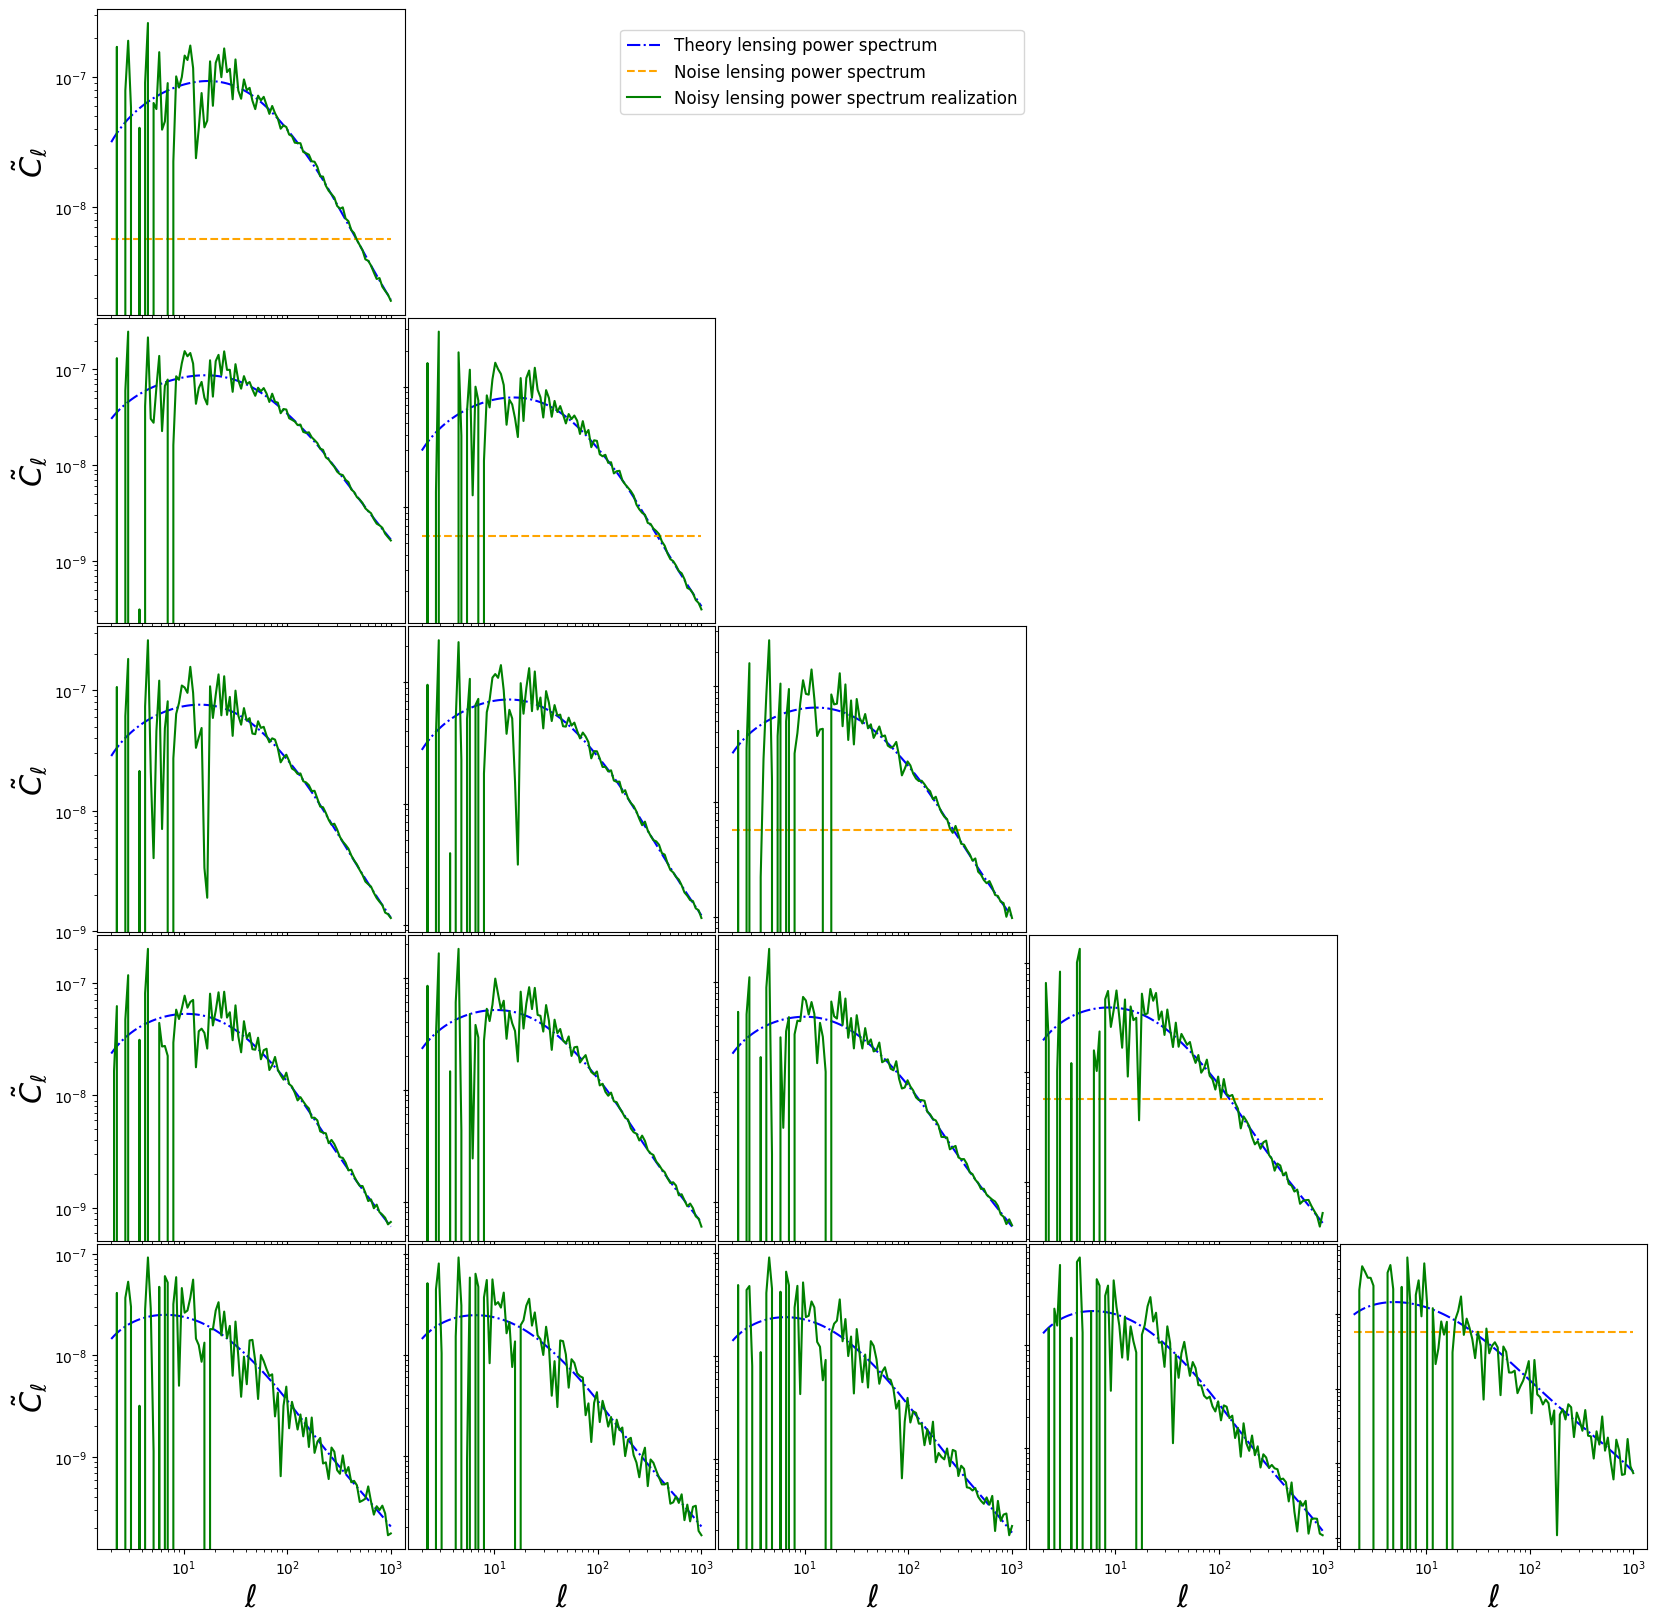

In [9]:
counter=0
fig, axs = plt.subplots(len(nzs), len(nzs), figsize=(20, 20))

cls_plot = cls[::-1]
noise_cls_plot = noise_cls[::-1]
cls_noise_plot = cls_noise.reshape(cls.shape)[::-1]

for i in range(0, len(nzs)):
    for j in range(0, len(nzs)):
        if i<j:
            axs[i, j].axis('off')
        else:
            axs[i, j].plot(ell, cls_plot[counter], c='blue', ls = '-.', label='Theory lensing power spectrum')
            axs[i, j].plot(ell, noise_cls_plot[counter], c='orange', ls = '--', label='Noise lensing power spectrum')
            axs[i, j].plot(ell, cls_noise_plot[counter], c='green', ls = '-', label='Noisy lensing power spectrum realization')
            axs[i, j].set_xscale('log')
            axs[i, j].set_yscale('log')

            if i == len(nzs) - 1:
                axs[i, j].set_xlabel(r'$\ell$', fontsize=22)
            else:
                plt.setp(axs[i, j].get_xticklabels(), visible=False)
            
            if j == 0:
                axs[i, j].set_ylabel(r'$\tilde{C}_{\ell}$', fontsize=22)
            else:
                plt.setp(axs[i, j].get_yticklabels(), visible=False)

            counter += 1

plt.legend(bbox_to_anchor=(-1, 5), loc='upper right', fontsize=12)
plt.subplots_adjust(wspace=0.01, hspace=0.01)
plt.show()

## Let's turn this into jax vmappable simulator for efficiency

In [10]:
@jax.jit
def simulator(theta, key=jax.random.PRNGKey(42)):
    def single_sim(params, rng_key):
        cosmo = jc.Cosmology(
            sigma8=params[0],
            Omega_c=params[1],
            Omega_b=params[2],
            h=params[3],
            n_s=params[4],
            Omega_k=0.0,
            w0=-1.0,
            wa=0.0,
        )
        
        cls = jc.angular_cl.angular_cl(cosmo, ell, probes)
        cov = jc.angular_cl.gaussian_cl_covariance(ell, probes, cls, noise_cls, sparse=False)
        
        # Use JAX random generation instead of numpy
        return jax.random.multivariate_normal(rng_key, mean=jnp.concatenate(cls), cov=cov)

    # Split keys so each simulation gets a unique random seed
    keys = jax.random.split(key, theta.shape[0])
    
    # vmap the single simulation function over parameters and keys
    return jax.vmap(single_sim)(theta, keys)

In [11]:
def chunked_simulator(theta, chunk_size=100, key=jax.random.PRNGKey(42)):
    n_samples = theta.shape[0]
    n_chunks = int(np.ceil(n_samples / chunk_size))
    
    # Split the main key so each chunk gets a unique random state
    chunk_keys = jax.random.split(key, n_chunks)
    
    results = []
    for i in tqdm(range(n_chunks)):
        start = i * chunk_size
        end = min((i + 1) * chunk_size, n_samples)
        
        # Run the JIT-compiled simulator on the current batch
        batch_res = simulator(theta[start:end], key=chunk_keys[i])
        results.append(batch_res)
        
    return jnp.vstack(results)

## Set priors

Setting some flat priors for simplicity's sake


In [12]:
params = ['sigma_8', 'Omega_c', 'Omega_b', 'h', 'n_s']

lower = torch.tensor([0.5, 0.1, 0.04, 0.64, 0.84])
upper = torch.tensor([1.2, 0.5, 0.06, 0.82, 1.10])

prior = BoxUniform(low=lower, high=upper)

## Let's setup a compression method with CCA

Given the paired parameters and data,
$$
\begin{align}
\theta\in{\rm I\!R}^N,\;\;&\;\; X\in{\rm I\!R}^M \\
\end{align}
$$
we apply projection to both spaces.
$$
\begin{align}
\^{\theta}=U_\theta\theta\;,&\;\;\;\;U_\theta= \begin{pmatrix} w_1 & w_2 & \cdots & w_R \end{pmatrix}^T\\
\^{X}=U_XX\;,&\;\;\;\;U_X= \begin{pmatrix} v_1 & v_2 & \cdots & v_R \end{pmatrix}^T
\end{align}
$$
The vectors that form the compression matrix are solved via maximising the correlation in the projected space,
$$
w,\,v = \underset{w, v}{\operatorname{argmax}} \frac{w^{\top} \Sigma_{\theta X} v}{\sqrt{w^{\top} \Sigma_{\theta} w} \sqrt{v^{\top} \Sigma_{X} v}}
$$
where $\Sigma_{\theta X}$ is the cross covariance.
<br><br>Since we are seeking to compress the data vector $X$, we only need to find $v_1,...,v_R$. 

It would turn out that $R=min(N,M)$ due to the nature of the eigenvalue problem being solved when maximising the correlation.
$$
\Sigma_X^{-1}\Sigma_{X\theta}\Sigma_\theta^{-1}\Sigma_{\theta X} v = \lambda v
$$

In [13]:
def compute_cca_evecs(sim_samples, simulated_data):
    n_params = sim_samples.shape[1]

    cca_cov = np.cov(sim_samples.T, simulated_data.T)
    cp = cca_cov[:n_params, :n_params]
    cd = cca_cov[n_params:, n_params:]
    cpd = cca_cov[:n_params, n_params:]

    cl = cpd.T @ np.linalg.inv(cp) @ cpd

    evals, evecs = eigh(cd, cd - cl)

    evals = evals[::-1][:n_params]
    evecs = evecs[:, ::-1][:, :n_params]

    return evecs

## Now let's make a mock data vector with our simulator 

In [14]:
truth = [cosmo_data.sigma8, cosmo_data.Omega_c, cosmo_data.Omega_b, cosmo_data.h, cosmo_data.n_s]

In [15]:
mock_theta = torch.tensor([truth], dtype=torch.float32)
mock_obs = chunked_simulator(mock_theta.numpy(), chunk_size=1)[0]

100%|██████████| 1/1 [00:10<00:00, 10.42s/it]


## Let's try to do an explicit likelihood sampling run with a Gaussian likelihood

## Setup the Nautilus sampler

In [16]:
def _make_nautilus_prior():
    """Build a Nautilus Prior matching the BoxUniform bounds."""
    p = NautilusPrior()
    for name, lo, hi in zip(params, lower.numpy(), upper.numpy()):
        p.add_parameter(name, dist=st.uniform(loc=lo, scale=float(hi - lo)))
    return p


def run_nautilus(obs, cov, evecs=None, n_live=2000, n_networks=4, verbose=True):
    """
    Run Nautilus nested sampler with a Gaussian likelihood.

    Parameters
    ----------
    obs      : array-like, shape (n_data,)
        Observed data vector.  When evecs is provided this should already be
        the compressed observation (obs @ evecs); the covariance is compressed
        internally.
    cov      : array-like, shape (n_data_full, n_data_full)
        Full data covariance.  If evecs is provided it is compressed to
        ``evecs.T @ cov @ evecs`` before inversion; otherwise it is inverted
        directly.
    evecs    : array-like, shape (n_cls, n_compressed) or None
        CCA projection matrix.  When provided, the theory cls are projected
        via ``concat(cls) @ evecs`` and the covariance is compressed to match.
        Pass None to compare theory directly to obs without any projection.
    n_live : int
        Number of live points.
    n_networks : int
        Number of neural networks in the Nautilus ensemble.
    verbose : bool
        Print progress during sampling.

    Returns
    -------
    points  : np.ndarray, shape (n_samples, ndim)
    log_w   : np.ndarray, shape (n_samples,)   — log importance weights
    log_l   : np.ndarray, shape (n_samples,)   — log-likelihoods
    """
    obs_jax_ = jnp.asarray(obs)

    if evecs is not None:
        evecs_jax_ = jnp.asarray(evecs)
        evecs_np_  = np.asarray(evecs)
        cov_comp   = evecs_np_.T @ np.asarray(cov) @ evecs_np_
        cov_inv_jax_ = jnp.asarray(np.linalg.inv(cov_comp))

        def _single_like(p):
            cosmo = jc.Cosmology(
                sigma8=p[0], Omega_c=p[1], Omega_b=p[2],
                h=p[3], n_s=p[4], Omega_k=0., w0=-1., wa=0.)
            cls_ = jc.angular_cl.angular_cl(cosmo, ell, probes)
            theory = jnp.concatenate(cls_) @ evecs_jax_
            diff = obs_jax_ - theory
            return -0.5 * diff @ cov_inv_jax_ @ diff
    else:
        cov_inv_jax_ = jnp.asarray(np.linalg.inv(np.asarray(cov)))

        def _single_like(p):
            cosmo = jc.Cosmology(
                sigma8=p[0], Omega_c=p[1], Omega_b=p[2],
                h=p[3], n_s=p[4], Omega_k=0., w0=-1., wa=0.)
            cls_ = jc.angular_cl.angular_cl(cosmo, ell, probes)
            theory = jnp.concatenate(cls_)
            diff = obs_jax_ - theory
            return -0.5 * diff @ cov_inv_jax_ @ diff

    # ── batched evaluators ────────────────────────────────────────────────────
    @functools.partial(jax.pmap, axis_name='devices')
    def _pmap_batch(theta_shard):
        return jax.vmap(_single_like)(theta_shard)

    _vmap_batch = jax.jit(jax.vmap(_single_like))

    def _eval_batch(theta_batch):
        n = theta_batch.shape[0]
        if n_devices > 1:
            n_padded = max(n_devices, int(np.ceil(n / n_devices)) * n_devices)
            theta_padded = (
                jnp.concatenate(
                    [theta_batch, jnp.tile(theta_batch[:1], (n_padded - n, 1))],
                    axis=0,
                ) if n_padded > n else theta_batch
            )
            sharded = theta_padded.reshape(n_devices, -1, theta_batch.shape[-1])
            return np.asarray(_pmap_batch(sharded).reshape(-1)[:n])
        else:
            return np.asarray(_vmap_batch(theta_batch))

    def log_likelihood(param_dict):
        theta = jnp.stack(
            [jnp.asarray(param_dict[name]) for name in params], axis=-1
        )
        return _eval_batch(theta)

    # ── build sampler and run ─────────────────────────────────────────────────
    nautilus_prior = _make_nautilus_prior()
    print(f"Running Nautilus ({'compressed' if evecs is not None else 'uncompressed'}) | "
          f"n_live={n_live}  n_networks={n_networks}  ndim={len(params)}")

    sampler = NautilusSampler(
        nautilus_prior, log_likelihood,
        n_live=n_live, n_networks=n_networks,
        vectorized=True,
    )
    sampler.run(verbose=verbose)

    points, log_w, log_l = sampler.posterior()
    if isinstance(points, dict):
        points = np.column_stack([points[name] for name in params])

    print(f"Posterior samples: {points.shape[0]}")
    return np.asarray(points), np.asarray(log_w), np.asarray(log_l)

### Now let's get the ground truth with nautilus

In [17]:
# Pre-convert static arrays to JAX arrays once
mock_obs_jax       = jnp.asarray(np.asarray(mock_obs))
cov_np             = np.asarray(cov)

n_devices = jax.device_count()
print(f"JAX devices: {n_devices}")

JAX devices: 1


In [18]:
nautilus_points_true_post, nautilus_log_w_true_post, nautilus_log_l_true_post = run_nautilus(
    obs=mock_obs_jax,
    cov=cov_np,
    n_live=2000,
)

Running Nautilus (uncompressed) | n_live=2000  n_networks=4  ndim=5
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 23     | 1        | 4        | 48900    | N/A    | 14557 | -742.91  
Posterior samples: 48900


### Let's try doing nautilus with CCA compression from the prior

In [19]:
compression_samples_prior = prior.sample((10000,)).numpy()
compression_data_prior = chunked_simulator(compression_samples_prior, chunk_size=250)

100%|██████████| 40/40 [01:07<00:00,  1.70s/it]


In [20]:
evecs_prior = compute_cca_evecs(compression_samples_prior, compression_data_prior)
compressed_obs_prior = torch.as_tensor(np.asarray(mock_obs@evecs_prior).copy(), dtype=torch.float32)

In [22]:
evecs_prior_jax = jnp.asarray(evecs_prior)
compressed_obs_prior_jax = jnp.asarray(compressed_obs_prior.numpy())

nautilus_points_prior_compressed, nautilus_log_w_prior_compressed, nautilus_log_l_prior_compressed = run_nautilus(
    obs=compressed_obs_prior_jax,
    cov=cov_np,
    evecs=evecs_prior_jax,
    n_live=2000,
)

Running Nautilus (compressed) | n_live=2000  n_networks=4  ndim=5
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    


Finished  | 15     | 1        | 4        | 33100    | N/A    | 13139 | -6.18    
Posterior samples: 33100


### Now let's try nautilius with the intermediate posterior from 1 round of ELI

In [23]:
# Draw posterior samples from the Nautilus run
compression_samples_post_1 = draw_weighted_posterior_samples(
    nautilus_points_prior_compressed,
    nautilus_log_w_prior_compressed,
    n_draws=10000,
)

compression_data_post_1 = chunked_simulator(
    compression_samples_post_1,
    chunk_size=250,
    key=jax.random.PRNGKey(1234),
)

100%|██████████| 40/40 [01:07<00:00,  1.68s/it]


In [24]:
evecs_post_1 = compute_cca_evecs(compression_samples_post_1, compression_data_post_1)
compressed_obs_post_1 = torch.as_tensor(np.asarray(mock_obs@evecs_post_1).copy(), dtype=torch.float32)

In [25]:
evecs_post_1_jax = jnp.asarray(evecs_post_1)
compressed_obs_post_1_jax = jnp.asarray(compressed_obs_post_1.numpy())

nautilus_points_post_1_compressed, nautilus_log_w_post_1_compressed, nautilus_log_l_post_1_compressed = run_nautilus(
    obs=compressed_obs_post_1_jax,
    cov=cov_np,
    evecs=evecs_post_1_jax,
    n_live=2000,
)

Running Nautilus (compressed) | n_live=2000  n_networks=4  ndim=5
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 22     | 1        | 4        | 48000    | N/A    | 14773 | -12.31   
Posterior samples: 48000


### Let's also try nautilius but using the ground truth posterior

In [26]:
compression_samples_true_post = draw_weighted_posterior_samples(
    nautilus_points_true_post,
    nautilus_log_w_true_post,
    n_draws=10000,
)

compression_data_true_post = chunked_simulator(
    compression_samples_true_post,
    chunk_size=250,
    key=jax.random.PRNGKey(100),
)

100%|██████████| 40/40 [00:57<00:00,  1.43s/it]


In [27]:
evecs_true_post = compute_cca_evecs(compression_samples_true_post, compression_data_true_post)
compressed_obs_true_post = torch.as_tensor(np.asarray(mock_obs@evecs_true_post).copy(), dtype=torch.float32)

In [28]:
evecs_true_post_jax = jnp.asarray(evecs_true_post)
compressed_obs_true_post_jax = jnp.asarray(compressed_obs_true_post.numpy())

nautilus_points_true_post_compressed, nautilus_log_w_true_post_compressed, nautilus_log_l_true_post_compressed = run_nautilus(
    obs=compressed_obs_true_post_jax,
    cov=cov_np,
    evecs=evecs_true_post_jax,
    n_live=2000,
)

Running Nautilus (compressed) | n_live=2000  n_networks=4  ndim=5
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 23     | 1        | 4        | 48100    | N/A    | 14785 | -11.28   
Posterior samples: 48100


## Make the corresponding getdist things

In [29]:
param_labels = [r'\sigma_8', r'\Omega_c', r'\Omega_b', r'h', r'n_s']
truth = [cosmo_data.sigma8, cosmo_data.Omega_c, cosmo_data.Omega_b, cosmo_data.h, cosmo_data.n_s]
truth_marker = dict(zip(params, truth))

### Prior compressed MC

In [30]:
nautilus_weights_prior_compressed = np.exp(
    nautilus_log_w_prior_compressed - nautilus_log_w_prior_compressed.max()
)
nautilus_weights_prior_compressed /= nautilus_weights_prior_compressed.sum()

nautilus_MC_prior_compressed = MCSamples(
    samples=nautilus_points_prior_compressed,
    weights=nautilus_weights_prior_compressed,
    loglikes=-nautilus_log_l_prior_compressed,
    names=params,
    labels=param_labels,
    label="Explicit Gaussian likelihood (CCA from prior)",
)



Removed no burn in


### Posterior 1 compressed MC

In [31]:
# Nautilus returns importance-weighted samples; pass weights to getdist
nautilus_weights_post_1 = np.exp(nautilus_log_w_post_1_compressed - nautilus_log_w_post_1_compressed.max())
nautilus_weights_post_1 /= nautilus_weights_post_1.sum()

nautilus_MC_post_1_compressed = MCSamples(
    samples=nautilus_points_post_1_compressed,
    weights=nautilus_weights_post_1,
    loglikes=-nautilus_log_l_post_1_compressed,
    names=params,
    labels=param_labels,
    label="Explicit Gaussian likelihood (CCA from posterior 1)",
)

Removed no burn in


### True posterior compressed MC

In [32]:
# Nautilus returns importance-weighted samples; pass weights to getdist
nautilus_weights_true_post_compressed = np.exp(nautilus_log_w_true_post_compressed - nautilus_log_w_true_post_compressed.max())
nautilus_weights_true_post_compressed /= nautilus_weights_true_post_compressed.sum()

nautilus_MC_true_post_compressed = MCSamples(
    samples=nautilus_points_true_post_compressed,
    weights=nautilus_weights_true_post_compressed,
    loglikes=-nautilus_log_l_true_post_compressed,
    names=params,
    labels=param_labels,
    label="Explicit Gaussian likelihood (CCA from true posterior)",
)

Removed no burn in


### True posterior

In [33]:
# Nautilus returns importance-weighted samples; pass weights to getdist
nautilus_weights_true_post = np.exp(nautilus_log_w_true_post - nautilus_log_w_true_post.max())
nautilus_weights_true_post /= nautilus_weights_true_post.sum()

nautilus_MC_truth = MCSamples(
    samples=nautilus_points_true_post,
    weights=nautilus_weights_true_post,
    loglikes=-nautilus_log_l_true_post,
    names=params,
    labels=param_labels,
    label="Explicit Gaussian likelihood (truth)",
)

Removed no burn in


# Plot this so far

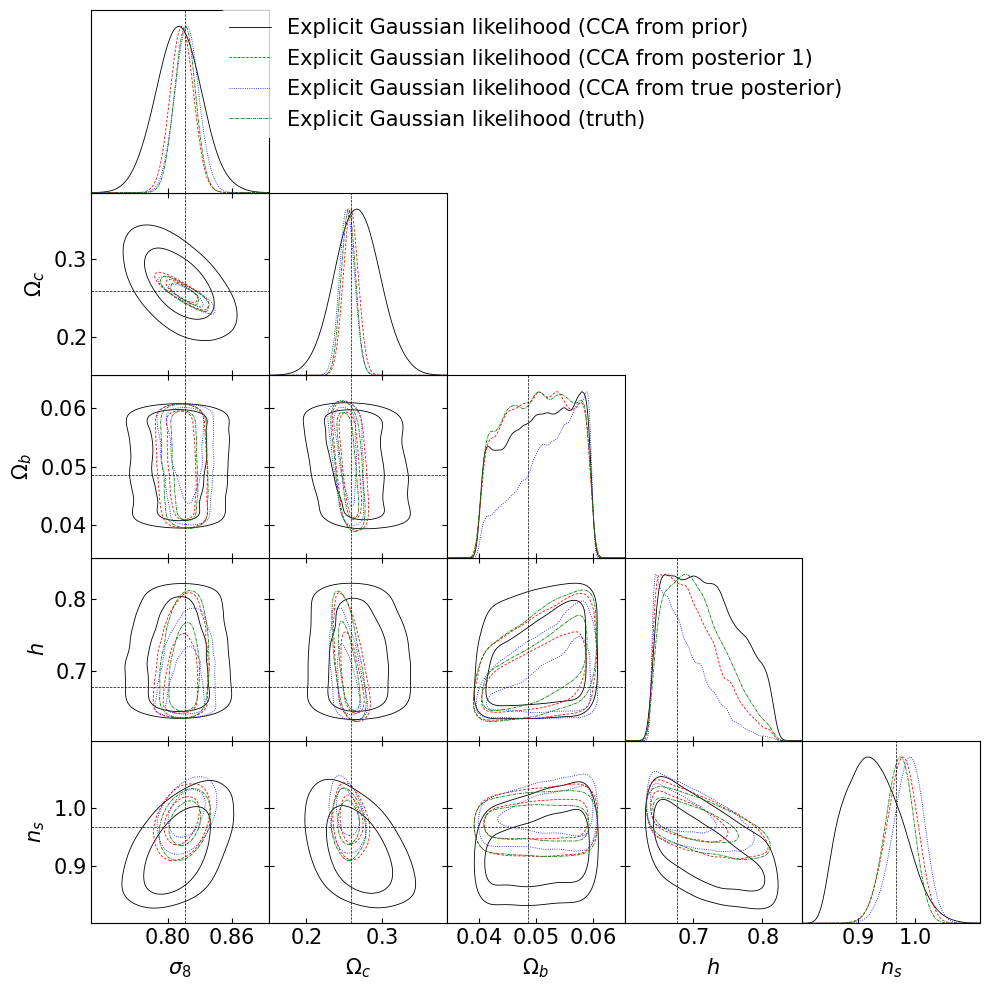

In [44]:
triangle_plot(
    [nautilus_MC_prior_compressed, nautilus_MC_post_1_compressed, nautilus_MC_true_post_compressed, nautilus_MC_truth],
    truth=truth_marker)

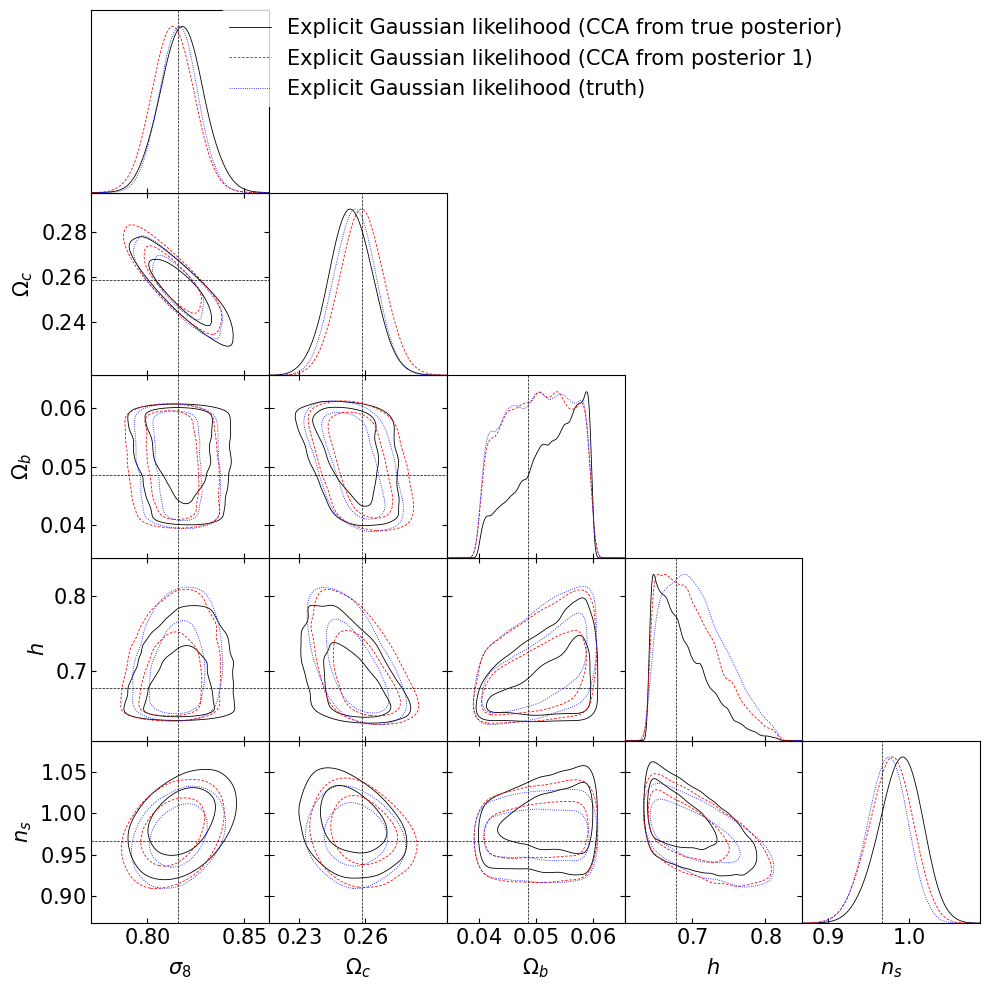

In [43]:
triangle_plot(
    [nautilus_MC_true_post_compressed, nautilus_MC_post_1_compressed, nautilus_MC_truth],
    truth=truth_marker)

# Now let's do some SBI with NLE

In [45]:
num_sims = 1000
num_rounds = 5
nle_inference = NLE(prior)
nle_proposal = prior

In [46]:
def run_nle(prior, nle_inference, evecs, mock_obs, num_sims=1000, num_rounds=5):
    compressed_obs = torch.tensor(np.asarray(mock_obs @ evecs).copy(), dtype=torch.float32)
    
    nle_proposal = prior
    for _ in range(num_rounds):
        theta = nle_proposal.sample((num_sims,))
        x = chunked_simulator(theta.detach().numpy(), chunk_size=250)
        compressed_x = torch.tensor(np.asarray(x) @ evecs, dtype=torch.float32)
        _ = nle_inference.append_simulations(theta, compressed_x).train()
        nle_posterior = nle_inference.build_posterior().set_default_x(compressed_obs)
        nle_proposal = nle_posterior

    nle_posterior_theta = nle_posterior.sample((20000,), x=compressed_obs, num_chains=100)
    nle_posterior_samples = nle_posterior_theta.detach().numpy()
    nle_posterior_log_probs = nle_posterior.potential(
        nle_posterior_theta.detach(), x=compressed_obs
    ).numpy()

    return nle_posterior_samples, nle_posterior_log_probs


## Run with samples from prior

In [48]:
nle_posterior_samples_prior_compressed, nle_posterior_log_probs_prior_compressed = run_nle(prior, nle_inference, evecs_prior, mock_obs)

100%|██████████| 4/4 [00:04<00:00,  1.08s/it]


 Neural network successfully converged after 58 epochs.

/home/klin/cosmology/cca_test/.venv/lib/python3.12/site-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

...

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:04<00:00,  1.09s/it]


 Neural network successfully converged after 24 epochs.

Generating 100 MCMC inits via resample strategy:   0%|          | 0/100 [00:00<?, ?it/s]

Running vectorized MCMC with 100 chains:   0%|          | 0/45000 [00:00<?, ?it/s]

In [53]:
nle_MC_prior_compressed = MCSamples(
    samples=nle_posterior_samples_prior_compressed, 
    loglikes=nle_posterior_log_probs_prior_compressed,
    names=params,
    labels=param_labels,
    label="NLE SBI (CCA from prior)",
    sampler="mcmc",
)

Removed no burn in


## Run samples from post 1

In [49]:
nle_compression_samples_post_1 = nle_posterior_samples_prior_compressed[
    np.random.choice(len(nle_posterior_samples_prior_compressed), size=10000, replace=False)
]

nle_compression_data_post_1 = chunked_simulator(
    nle_compression_samples_post_1,
    chunk_size=250,
    key=jax.random.PRNGKey(101),
)

100%|██████████| 40/40 [00:55<00:00,  1.40s/it]


In [ ]:
evecs_nle_post_1 = compute_cca_evecs(compression_samples_post_1, compression_data_post_1)

In [52]:
nle_posterior_samples_nle_post_1, nle_posterior_log_probs_nle_post_1 = run_nle(prior, nle_inference, evecs_nle_post_1, mock_obs)

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:04<00:00,  1.08s/it]


 Neural network successfully converged after 110 epochs.

/home/klin/cosmology/cca_test/.venv/lib/python3.12/site-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

...

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:04<00:00,  1.09s/it]


 Neural network successfully converged after 33 epochs.

Generating 100 MCMC inits via resample strategy:   0%|          | 0/100 [00:00<?, ?it/s]

Running vectorized MCMC with 100 chains:   0%|          | 0/45000 [00:00<?, ?it/s]

In [54]:
nle_MC_nle_post_1 = MCSamples(
    samples=nle_posterior_samples_nle_post_1, 
    loglikes=nle_posterior_log_probs_nle_post_1,
    names=params,
    labels=param_labels,
    label="NLE SBI (CCA from posterior 1)",
    sampler="mcmc",
)

Removed no burn in


## Plot!


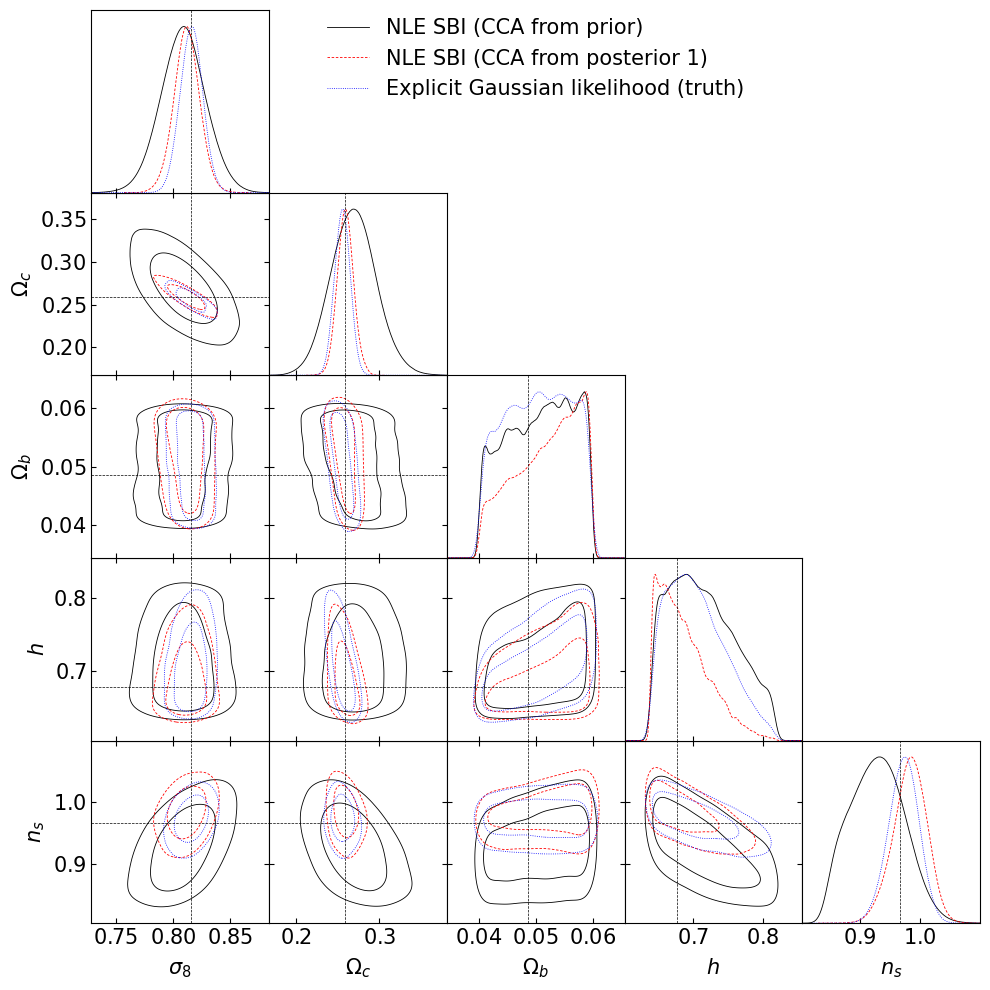

In [55]:
triangle_plot(
    [nle_MC_prior_compressed, nle_MC_nle_post_1, nautilus_MC_truth],
    truth=truth_marker)
